# Multi-Armed Bandit Experiments: Exploration, Exploitation, and Learning Rates

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set a random seed for reproducibility
np.random.seed(42)

We set a random seed for NumPy (`np.random.seed(42)`) to ensure that our experiments are reproducible. This means that every time this notebook is run, the random numbers generated (e.g., for bandit rewards, agent exploration choices, and initial true Q-values) will be the same, allowing for consistent results and easier debugging.

## Experiment Setup

To ensure robust results, we'll run multiple experiments and average their outcomes. This helps mitigate the impact of randomness inherent in bandit problems.

In [2]:
# Define global experiment parameters
NUM_ACTIONS = 10  # Number of arms/actions in the bandit problem
NUM_RUNS = 200    # Number of independent runs to average results over
NUM_STEPS = 1000  # Number of steps/plays in each run

## 1. 10-Armed Bandit Problem

The multi-armed bandit problem is a classic reinforcement learning scenario where an agent repeatedly chooses one of several 'arms' (actions) and receives a reward. Each arm has an unknown probability distribution of rewards. The goal is to maximize the total reward over time.

In this setup, we'll create a bandit environment with 10 actions. Each action has a 'true' (hidden) mean reward value, and the actual rewards received will be samples from a normal distribution around these true means.

In [3]:
class TenArmedBandit:
    """
    Represents a k-armed bandit problem.
    Each arm has a true mean reward, and actual rewards are drawn from a normal distribution.
    """

    def __init__(self, num_arms=10, stationary=True, q_true_mean=0, q_true_std=1):
        """
        Initializes the bandit environment.

        Args:
            num_arms (int): The number of arms (actions) in the bandit.
            stationary (bool): If True, true reward values are fixed (stationary environment).
                               If False, true reward values drift over time (non-stationary environment).
            q_true_mean (float): Mean for initializing true reward values.
            q_true_std (float): Standard deviation for initializing true reward values.
        """
        self.num_arms = num_arms
        self.stationary = stationary
        self.q_true_mean = q_true_mean
        self.q_true_std = q_true_std

        # Initialize true action values (q*) for each arm
        self.q_true = np.random.normal(q_true_mean, q_true_std, num_arms)
        self.optimal_action = np.argmax(self.q_true)

    def pull_arm(self, action):
        """
        Simulates pulling an arm and returns a reward.

        Args:
            action (int): The index of the arm to pull.

        Returns:
            float: The reward received for pulling the chosen arm.
        """
        # Rewards are drawn from a normal distribution with mean q_true[action] and std deviation 1
        reward = np.random.normal(self.q_true[action], 1)
        return reward

    def drift(self):
        """
        If in a non-stationary environment, causes the true action values to drift.
        """
        if not self.stationary:
            # Add a small random increment to each q_true value
            self.q_true += np.random.normal(0, 0.01, self.num_arms)
            self.optimal_action = np.argmax(self.q_true)


Let's visualize the true reward distributions for a single 10-armed bandit instance to understand the environment.

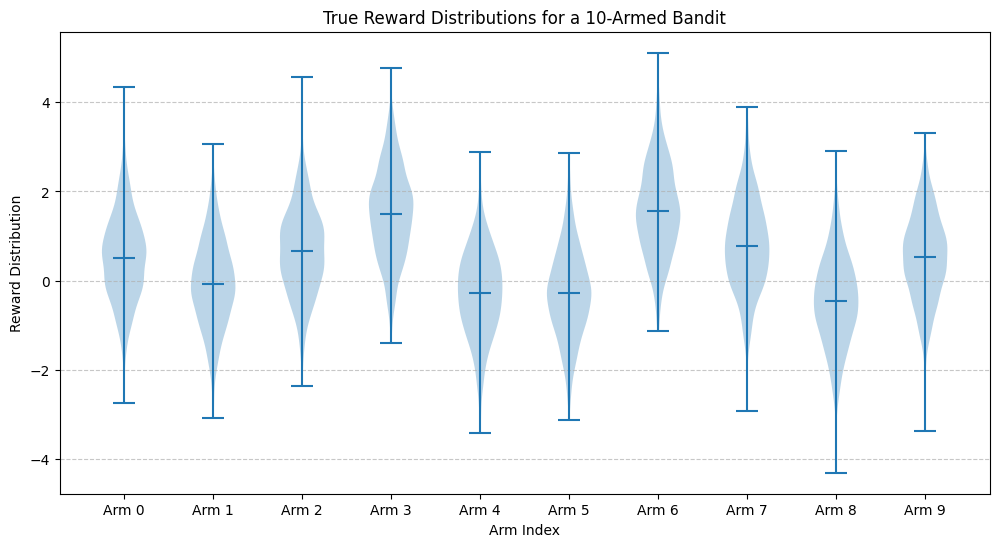

In [4]:
# Create a single bandit instance for demonstration
demo_bandit = TenArmedBandit(num_arms=NUM_ACTIONS)

# Generate a large number of samples for each arm to visualize the distribution
num_samples_per_arm = 1000
rewards_per_arm = [[] for _ in range(NUM_ACTIONS)]

for arm_idx in range(NUM_ACTIONS):
    # Temporarily set the bandit's q_true to generate rewards for this arm
    # In a real scenario, we'd just sample directly from the distribution based on demo_bandit.q_true[arm_idx]
    # For visualization, we'll simulate pulls
    for _ in range(num_samples_per_arm):
        rewards_per_arm[arm_idx].append(np.random.normal(demo_bandit.q_true[arm_idx], 1))

plt.figure(figsize=(12, 6))
plt.violinplot(rewards_per_arm, showmeans=True, showextrema=True)
plt.xlabel('Arm Index')
plt.ylabel('Reward Distribution')
plt.title('True Reward Distributions for a 10-Armed Bandit')
plt.xticks(np.arange(1, NUM_ACTIONS + 1), labels=[f'Arm {i}' for i in range(NUM_ACTIONS)])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Interpretation:

The violin plot above illustrates the reward distributions for each of the 10 arms. Each 'violin' shape represents the probability density of rewards for a specific arm, with the wider sections indicating more frequent reward values. The white dot inside each violin shows the mean (the true `q_true` value for that arm), and the thin line extends to show the range of sampled rewards. We can observe that each arm has a distinct mean reward, but due to the standard deviation of 1, their distributions can overlap. The agent's task is to identify the arm with the highest true mean reward through repeated interaction, without prior knowledge of these distributions.

## 2. Exploration vs. Exploitation

In reinforcement learning, particularly in multi-armed bandit problems, an agent faces a fundamental dilemma: exploration versus exploitation.

*   **Exploitation:** This means choosing the action that currently has the highest estimated value. It leverages the knowledge gained so far to maximize immediate reward. If an arm has consistently given good rewards, an exploitative strategy would continue to pick that arm.

*   **Exploration:** This means trying out new or less-chosen actions, even if their current estimated values are not the highest. The goal of exploration is to discover potentially better actions that might yield higher rewards in the long run, thereby improving the agent's knowledge about the environment.

The challenge lies in finding a balance. Pure exploitation can lead to getting stuck on a suboptimal action if the initial estimates were misleading. Pure exploration, on the other hand, might waste too many opportunities by picking poor actions, even if good ones are already known. An effective agent needs both to perform well over time.

## 3. Random Tie-Breaking Argmax

When an agent needs to choose the action with the highest estimated value, it often uses an `argmax` function. However, standard `np.argmax()` is biased: if multiple actions share the same maximum value, it consistently returns the *first* index it encounters. This can lead to undesirable behavior, as some optimal actions might be unfairly neglected.

To ensure fair exploration among equally good actions (or equally poor actions if all values are low), we need a custom `argmax` function that randomly breaks ties. This way, if actions 0, 3, and 7 all have the highest estimated value, our function will randomly choose one of them, rather than always picking 0.

In [5]:
def custom_argmax(q_values):
    """
    Returns the index of the maximum value in q_values, breaking ties randomly.

    Args:
        q_values (np.array): Array of estimated action values.

    Returns:
        int: Index of the chosen action.
    """
    max_value = np.max(q_values)
    # Find all indices where the value equals the maximum value
    max_indices = np.where(q_values == max_value)[0]
    # Randomly choose one of these indices
    return np.random.choice(max_indices)

### Test and Visualization for Custom Argmax

Let's demonstrate how our `custom_argmax` differs from `np.argmax` when ties are present. We'll create an array of `q_values` with multiple identical maximum values and observe the selections over many trials.

Q-values with ties: [1.  2.5 2.5 1.5 2.5 0.5]
Maximum value: 2.5
Indices of maximum values: [1 2 4]


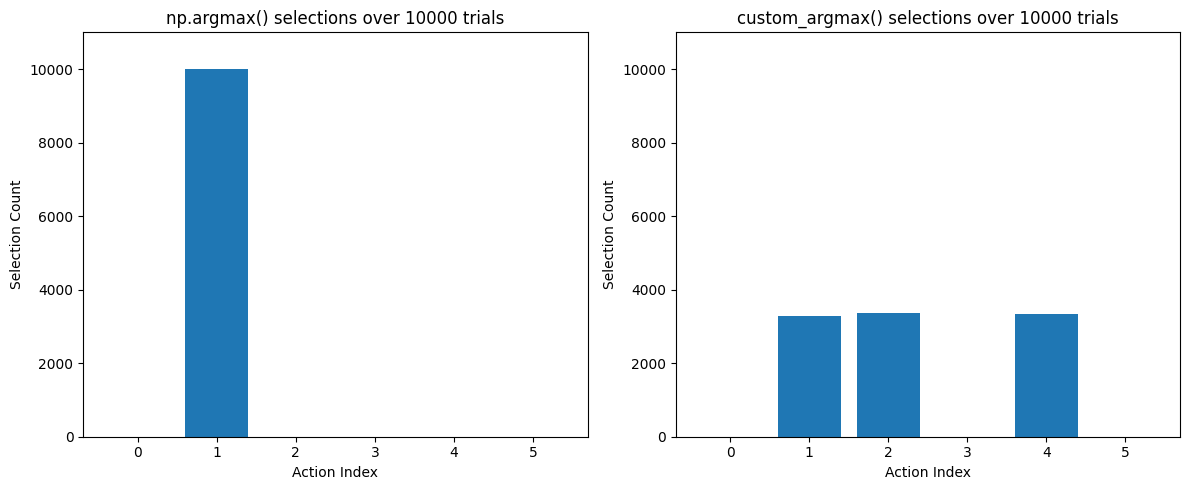

In [6]:
q_values_tied = np.array([1.0, 2.5, 2.5, 1.5, 2.5, 0.5])
num_trials = 10000

# Test np.argmax()
numpy_argmax_selections = [np.argmax(q_values_tied) for _ in range(num_trials)]
numpy_argmax_counts = np.bincount(numpy_argmax_selections, minlength=len(q_values_tied))

# Test custom_argmax()
custom_argmax_selections = [custom_argmax(q_values_tied) for _ in range(num_trials)]
custom_argmax_counts = np.bincount(custom_argmax_selections, minlength=len(q_values_tied))

print(f"Q-values with ties: {q_values_tied}")
print(f"Maximum value: {np.max(q_values_tied)}")
print(f"Indices of maximum values: {np.where(q_values_tied == np.max(q_values_tied))[0]}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(range(len(q_values_tied)), numpy_argmax_counts)
plt.title(f'np.argmax() selections over {num_trials} trials')
plt.xlabel('Action Index')
plt.ylabel('Selection Count')
plt.xticks(range(len(q_values_tied)))
plt.ylim(0, num_trials * 1.1)

plt.subplot(1, 2, 2)
plt.bar(range(len(q_values_tied)), custom_argmax_counts)
plt.title(f'custom_argmax() selections over {num_trials} trials')
plt.xlabel('Action Index')
plt.ylabel('Selection Count')
plt.xticks(range(len(q_values_tied)))
plt.ylim(0, num_trials * 1.1)

plt.tight_layout()
plt.show()

### Interpretation:

The bar charts clearly illustrate the difference. The left plot, using `np.argmax()`, shows that only the first action with the maximum value (index 1 in this case, `2.5`) was ever selected, despite other actions (indices 2 and 4, also `2.5`) having the same highest value. This confirms the bias of `np.argmax()`.

In contrast, the right plot, using our `custom_argmax()` function, shows that actions 1, 2, and 4 (all with value `2.5`) were selected approximately equally often. This demonstrates that `custom_argmax()` successfully breaks ties randomly, providing a fairer and less biased action selection mechanism crucial for effective exploration.

## 4. Greedy Agent

A greedy agent is the simplest form of action selection, characterized by an exploration rate `epsilon = 0`. This means the agent *always* chooses the action with the highest estimated value. It exclusively focuses on exploitation.

While this approach seems intuitive (always pick the best-known option), it has a significant drawback: if the initial estimates of action values are inaccurate (which is common at the start of learning), the greedy agent can get stuck exploiting a suboptimal action. It will never try other actions to discover if they might be better, thus limiting its long-term performance.

We will now implement a greedy agent and simulate its performance over many steps and runs to observe its learning behavior, average reward, and how often it selects the truly optimal action.

In [7]:
class Agent:
    """
    Base class for a Reinforcement Learning agent.
    """

    def __init__(self, num_actions, epsilon=0.0, alpha=0.1, initial_q=0.0, use_constant_alpha=False):
        """
        Initializes the agent.

        Args:
            num_actions (int): The number of possible actions.
            epsilon (float): The probability of choosing a random action (exploration).
            alpha (float): The step-size parameter for updating action values.
            initial_q (float): Initial estimate for all action values.
            use_constant_alpha (bool): If True, use constant step-size (alpha); otherwise, use sample-average (1/N).
        """
        self.num_actions = num_actions
        self.epsilon = epsilon
        self.alpha = alpha
        self.initial_q = initial_q
        self.use_constant_alpha = use_constant_alpha

        # Estimated action values (Q(a))
        self.q_estimates = np.full(num_actions, initial_q, dtype=float)
        # Number of times each action has been taken (N(a))
        self.action_counts = np.zeros(num_actions, dtype=int)

    def choose_action(self):
        """
        Selects an action based on the epsilon-greedy policy.

        Returns:
            int: The chosen action index.
        """
        if np.random.rand() < self.epsilon:
            # Explore: choose a random action
            return np.random.randint(self.num_actions)
        else:
            # Exploit: choose the best-known action (using custom_argmax for tie-breaking)
            return custom_argmax(self.q_estimates)

    def update_q_value(self, action, reward):
        """
        Updates the estimated value of the chosen action using either sample-average or constant step-size.

        Args:
            action (int): The action taken.
            reward (float): The reward received from taking the action.
        """
        self.action_counts[action] += 1

        if self.use_constant_alpha:
            # Constant step-size update rule: Q_new = Q_old + alpha * (R - Q_old)
            self.q_estimates[action] += self.alpha * (reward - self.q_estimates[action])
        else:
            # Sample-average update rule: Q_new = Q_old + (1/N) * (R - Q_old)
            self.q_estimates[action] += (1 / self.action_counts[action]) * (reward - self.q_estimates[action])

    def reset(self):
        """
        Resets the agent's internal state for a new run.
        """
        self.q_estimates = np.full(self.num_actions, self.initial_q, dtype=float)
        self.action_counts = np.zeros(self.num_actions, dtype=int)


In [8]:
def simulate_runs(agent_configs, num_runs, num_steps, num_actions, stationary=True):
    """
    Run multiple bandit experiments and record each agent's performance.

    This function is used for both stationary and non-stationary bandit experiments.

    Args:
        agent_configs (list): List of dictionaries.
            Each dictionary must contain:
            - "agent": an agent object
            - "label": a string name for the agent

        num_runs (int): Number of independent experiments.
        num_steps (int): Number of steps per experiment.
        num_actions (int): Number of bandit arms/actions.
        stationary (bool):
            True  = true action values stay fixed.
            False = true action values drift over time.

    Returns:
        all_rewards (dict):
            Rewards for each agent with shape (num_runs, num_steps).

        all_optimal_actions (dict):
            1 if the agent selected the current optimal action, otherwise 0.

        best_possible_rewards (np.array):
            The true value of the optimal action for each run (at the start).
    """

    # Create storage for rewards and optimal-action selections
    all_rewards = {
        config["label"]: np.zeros((num_runs, num_steps))
        for config in agent_configs
    }

    all_optimal_actions = {
        config["label"]: np.zeros((num_runs, num_steps))
        for config in agent_configs
    }

    best_possible_rewards = np.zeros(num_runs)

    # Repeat the experiment many times to reduce randomness
    for run in range(num_runs):

        # Create a fresh bandit environment for each run
        bandit = TenArmedBandit(num_arms=num_actions, stationary=stationary)
        best_possible_rewards[run] = np.max(bandit.q_true) # Store initial best possible reward

        # Reset all agents at the start of each run
        for config in agent_configs:
            config["agent"].reset()

        # Run the interaction for num_steps
        for step in range(num_steps):

            # Each agent interacts with the same bandit environment
            for config in agent_configs:
                agent = config["agent"]
                label = config["label"]

                # Agent chooses an action using its policy
                action = agent.choose_action()

                # Environment gives a reward for that action
                reward = bandit.pull_arm(action)

                # Agent updates its estimated value for the chosen action
                agent.update_q_value(action, reward)

                # Store the reward
                all_rewards[label][run, step] = reward

                # Store whether the chosen action was the current true best action
                all_optimal_actions[label][run, step] = int(action == bandit.optimal_action)

            # In a non-stationary environment, the true values change over time.
            # We drift after the agents act, so the change affects the next step.
            if not stationary:
                bandit.drift()

    return all_rewards, all_optimal_actions, best_possible_rewards

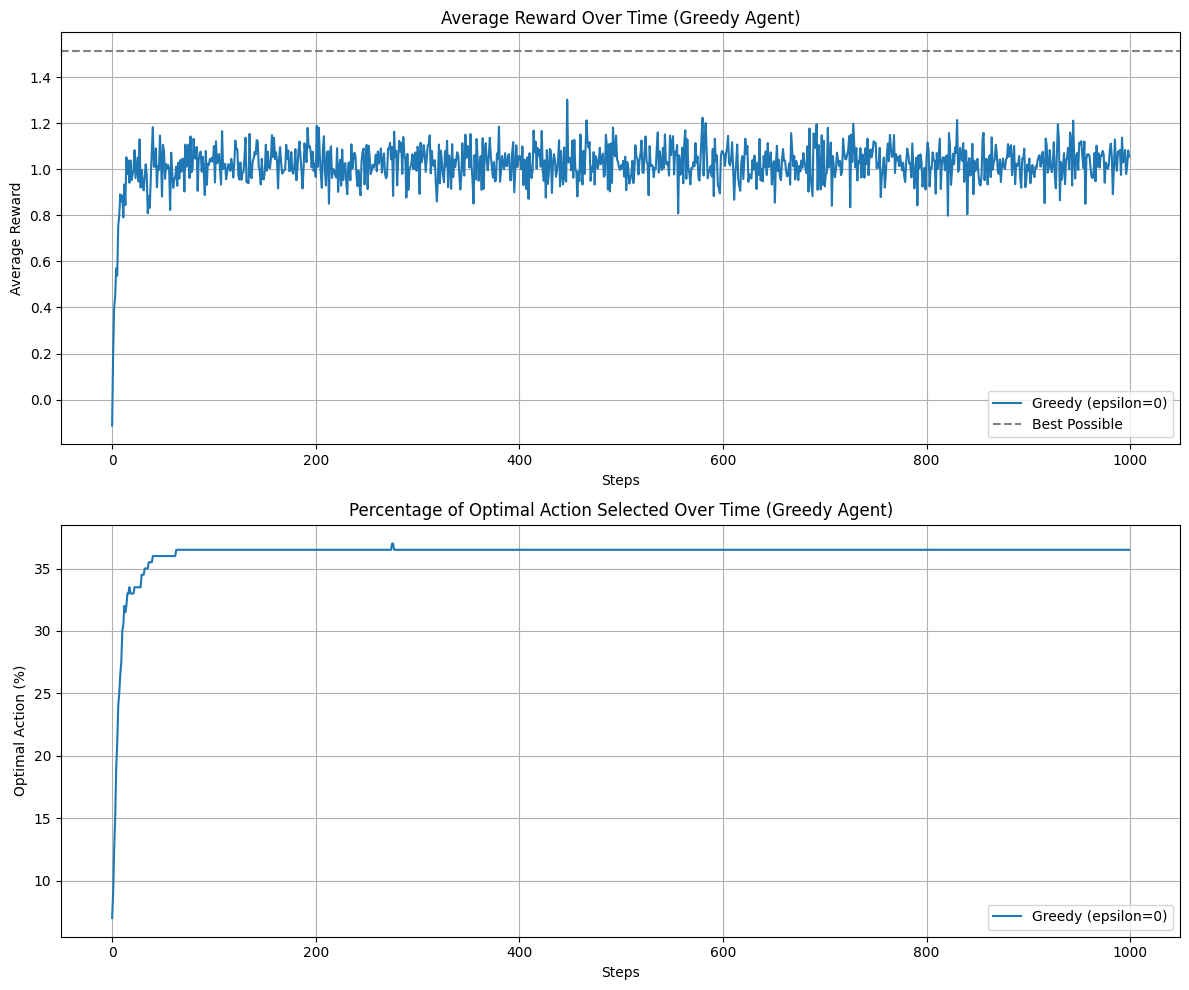

In [9]:
# Initialize a greedy agent (epsilon = 0) with sample-average update
greedy_agent = Agent(num_actions=NUM_ACTIONS, epsilon=0.0, use_constant_alpha=False)

# Configure agents for simulation
agent_configs = [
    {'label': 'Greedy (epsilon=0)', 'agent': greedy_agent}
]

# Run the simulation
greedy_rewards, greedy_optimal_actions, greedy_best_possible_rewards = simulate_runs(
    agent_configs, NUM_RUNS, NUM_STEPS, NUM_ACTIONS, stationary=True
)

# Calculate average rewards and optimal action percentages
avg_rewards = {label: np.mean(rewards, axis=0) for label, rewards in greedy_rewards.items()}
optimal_action_percentage = {label: np.mean(actions, axis=0) * 100 for label, actions in greedy_optimal_actions.items()}

# Plotting results
plt.figure(figsize=(12, 10))

plt.subplot(2, 1, 1)
for label, rewards in avg_rewards.items():
    plt.plot(rewards, label=label)
plt.axhline(
    y=np.mean(greedy_best_possible_rewards),
    linestyle="--",
    color='gray',
    label="Best Possible"
)
plt.title('Average Reward Over Time (Greedy Agent)')
plt.xlabel('Steps')
plt.ylabel('Average Reward')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
for label, percentages in optimal_action_percentage.items():
    plt.plot(percentages, label=label)
plt.title('Percentage of Optimal Action Selected Over Time (Greedy Agent)')
plt.xlabel('Steps')
plt.ylabel('Optimal Action (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Interpretation:

The graphs vividly illustrate the limitations of a purely greedy approach. The **Average Reward Over Time** plot shows that the greedy agent's reward quickly plateaus, often at a suboptimal level. This is because once it finds an action that appears best initially (due to random chance or early favorable rewards), it sticks with it, never exploring other actions that might actually be superior.

The **Percentage of Optimal Action Selected Over Time** plot further reinforces this. The greedy agent rarely reaches 100% optimal action selection. It quickly converges to selecting *an* action it believes is best, but this action is not necessarily the *truly* optimal one. The agent gets "stuck" on a locally optimal solution, failing to find the global optimum due to its complete lack of exploration.

## 5. Epsilon-Greedy Agent

The Epsilon-Greedy ($\epsilon$-greedy) strategy is a popular and effective method for balancing exploration and exploitation. It introduces a parameter, $\epsilon$ (epsilon), which dictates the probability of exploring versus exploiting.

Here's how it works:

*   **With probability $\epsilon$**: The agent chooses a random action (exploration). This allows the agent to try out actions it hasn't favored before, potentially discovering better options.
*   **With probability $1 - \epsilon$**: The agent chooses the action with the highest estimated value (exploitation). This leverages the current knowledge to maximize immediate reward.

This simple rule ensures that the agent occasionally explores, preventing it from getting stuck on suboptimal actions, while still primarily focusing on exploiting what it believes to be the best action. The value of $\epsilon$ is crucial: a small $\epsilon$ means more exploitation, while a large $\epsilon$ means more exploration. Our `Agent` class already incorporates this logic in its `choose_action` method.

## 6. Compare Epsilon Values

The choice of $\epsilon$ is critical for the performance of an $\epsilon$-greedy agent. We will now compare several $\epsilon$ values to understand their impact:

*   $\epsilon = 0$: Purely greedy agent, no exploration.
*   $\epsilon = 0.01$: Very little exploration, mostly exploitation.
*   $\epsilon = 0.1$: A common balance between exploration and exploitation.
*   $\epsilon = 0.4$: High exploration, potentially sacrificing immediate rewards for more learning.

We expect to see how exploration helps overcome the limitations of the purely greedy approach, but also how too much exploration can be detrimental.

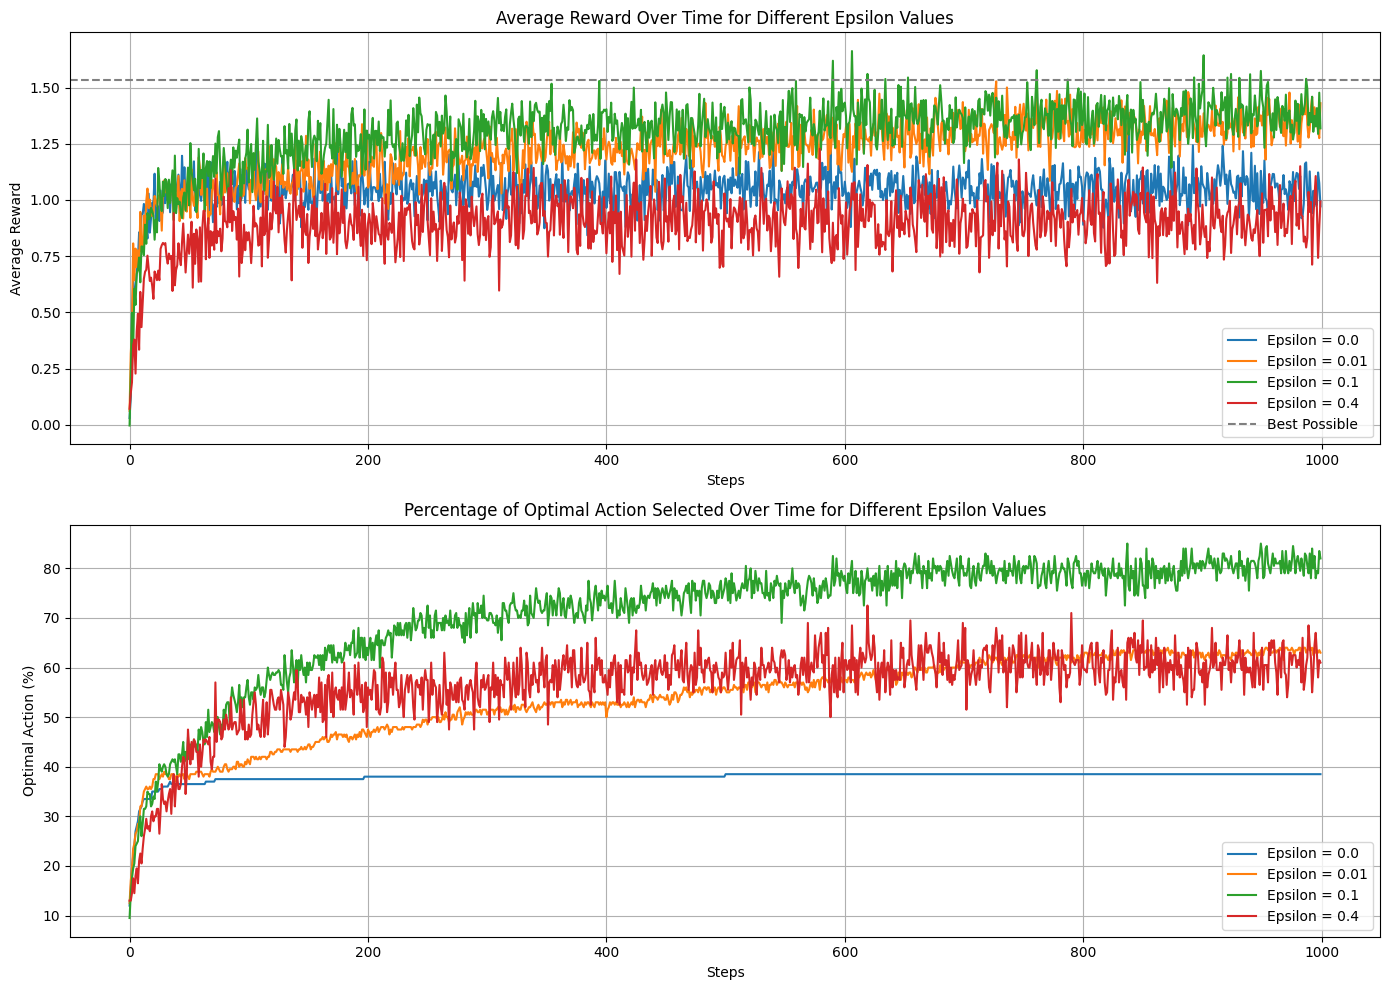

In [10]:
# Define different epsilon values to compare
epsilons = [0.0, 0.01, 0.1, 0.4]

# Prepare agent configurations for simulation (using sample-average update as default)
agent_configs_epsilon_comparison = []
for eps in epsilons:
    agent = Agent(num_actions=NUM_ACTIONS, epsilon=eps, use_constant_alpha=False)
    agent_configs_epsilon_comparison.append({'label': f'Epsilon = {eps}', 'agent': agent})

# Run the simulation for all agents
epsilon_rewards, epsilon_optimal_actions, epsilon_best_possible_rewards = simulate_runs(
    agent_configs_epsilon_comparison, NUM_RUNS, NUM_STEPS, NUM_ACTIONS, stationary=True
)

# Calculate average rewards and optimal action percentages for each epsilon
avg_rewards_epsilon = {label: np.mean(rewards, axis=0) for label, rewards in epsilon_rewards.items()}
optimal_action_percentage_epsilon = {label: np.mean(actions, axis=0) * 100 for label, actions in epsilon_optimal_actions.items()}

# Plotting results
plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
for label, rewards in avg_rewards_epsilon.items():
    plt.plot(rewards, label=label)
plt.axhline(
    y=np.mean(epsilon_best_possible_rewards),
    linestyle="--",
    color='gray',
    label="Best Possible"
)
plt.title('Average Reward Over Time for Different Epsilon Values')
plt.xlabel('Steps')
plt.ylabel('Average Reward')
plt.legend(loc='lower right')
plt.grid(True)

plt.subplot(2, 1, 2)
for label, percentages in optimal_action_percentage_epsilon.items():
    plt.plot(percentages, label=label)
plt.title('Percentage of Optimal Action Selected Over Time for Different Epsilon Values')
plt.xlabel('Steps')
plt.ylabel('Optimal Action (%)')
plt.legend(loc='lower right')
plt.grid(True)

plt.tight_layout()
plt.show()

### Interpretation:

The plots clearly demonstrate the trade-offs associated with different $\epsilon$ values:

*   **$\epsilon = 0$ (Greedy Agent):** As observed before, this agent quickly plateaus at a suboptimal reward and rarely selects the true optimal action. Its lack of exploration prevents it from discovering better options.

*   **$\epsilon = 0.01$ (Low Exploration):** This agent explores very little. It learns slowly, and while it eventually might find a better action than the purely greedy agent, its progress is significantly slower than agents with higher $\epsilon$ values. It struggles to overcome initial misleading estimates.

*   **$\epsilon = 0.1$ (Balanced Exploration):** This epsilon value generally provides a good balance. It explores enough to discover the truly optimal actions and quickly converges towards high average rewards and a high percentage of optimal action selections. This is often a good default choice for many bandit problems.

*   **$\epsilon = 0.4$ (High Exploration):** While this agent explores a lot, which helps it quickly identify the optimal action, its high exploration rate means it frequently chooses random actions even after identifying a good one. This leads to a lower average reward compared to $\epsilon = 0.1$ because it wastes too many plays on suboptimal random choices, even if its knowledge of the optimal action is strong. The high exploration makes its performance more "noisy" and less efficient in exploiting known good actions.

In [11]:
import pandas as pd

# Prepare data for the summary table for epsilon comparison
epsilon_labels = [config['label'] for config in agent_configs_epsilon_comparison]
epsilon_final_rewards = [rewards[-1] for rewards in avg_rewards_epsilon.values()]
epsilon_final_optimal_percentages = [percentages[-1] for percentages in optimal_action_percentage_epsilon.values()]

epsilon_summary = pd.DataFrame({
    "Agent": epsilon_labels,
    "Final Average Reward": epsilon_final_rewards,
    "Final Optimal Action %": epsilon_final_optimal_percentages
})
display(epsilon_summary)

,Agent,Final Average Reward,Final Optimal Action %
0,Epsilon = 0.0,0.971581,38.5
1,Epsilon = 0.01,1.430282,63.0
2,Epsilon = 0.1,1.318494,82.0
3,Epsilon = 0.4,0.993180,61.0


## 7. Sample-Average Update Rule

The `Agent` class we've implemented so far uses the **Sample-Average Update Rule** to estimate the value of each action. This rule calculates the estimated value of an action $A$, denoted as $Q[A]$, by averaging all the rewards received so far when action $A$ was chosen.

The formula for the sample-average update is:

$$Q_{new}[A] = Q_{old}[A] + \frac{1}{N[A]} \cdot (R - Q_{old}[A])$$

Where:
*   $Q_{new}[A]$ is the updated estimated value of action A.
*   $Q_{old}[A]$ is the previous estimated value of action A.
*   $N[A]$ is the number of times action A has been chosen so far.
*   $R$ is the reward received after taking action A at the current step.
*   $(R - Q_{old}[A])$ is the *error* in the estimate; it's how much the actual reward differed from what the agent expected.

### Explanation:

This formula effectively computes a running average. Each time an action $A$ is taken and a reward $R$ is received:

1.  The agent calculates the difference between the actual reward $R$ and its current estimate $Q_{old}[A]$.
2.  It then adjusts $Q_{old}[A]$ by a fraction of this difference. The fraction is $1/N[A]$.

#### Key Characteristics:

*   **Equal Weighting:** The $1/N[A]$ factor means that all past rewards for action $A$ are given equal weight in the average. It's truly an arithmetic mean of all rewards received for that action.
*   **Diminishing Impact of New Rewards:** As an action $A$ is chosen more and more times, $N[A]$ increases. Consequently, the term $1/N[A]$ becomes smaller and smaller. This implies that new rewards have less and less influence on the estimated value $Q[A]$ as $N[A]$ gets large. The estimate becomes more stable but also slower to adapt to changes.

This method works very well in *stationary* environments where the true reward values of actions do not change over time. However, its diminishing learning rate can be a disadvantage in *non-stationary* environments.

## 8. Constant Step-Size Update Rule

In contrast to the sample-average method, the **Constant Step-Size Update Rule** uses a fixed learning rate, often denoted by $\alpha$ (alpha). This means that every new reward always has the same fixed influence on the action value estimate, regardless of how many times the action has been taken before.

The formula for the constant step-size update is:

$$Q_{new}[A] = Q_{old}[A] + \alpha \cdot (R - Q_{old}[A])$$

Where:
*   $Q_{new}[A]$ is the updated estimated value of action A.
*   $Q_{old}[A]$ is the previous estimated value of action A.
*   $\alpha$ is the constant step-size (learning rate), typically a small positive value (e.g., 0.1).
*   $R$ is the reward received after taking action A at the current step.
*   $(R - Q_{old}[A])$ is the *error* in the estimate.

### Explanation:

This update rule works similarly to sample-average in that it adjusts the estimated value based on the error. However, the crucial difference is the step-size term:

#### Key Characteristics:

*   **Fixed Influence:** The $\alpha$ term remains constant. This means that new rewards always contribute a fixed proportion to the update of $Q[A]$.
*   **Values Recent Information:** Because $\alpha$ doesn't decrease over time (like $1/N[A]$ does), this method gives more weight to recent rewards. This makes it particularly suitable for **non-stationary environments**, where the true values of actions might change over time, and older information may no longer be relevant.
*   **Potential for Noise:** A constant step-size can also make the estimates more susceptible to noise, as even after many experiences, a single, particularly high or low reward can still significantly shift the estimate. If $\alpha$ is too large, the estimates might oscillate around the true value rather than converging smoothly.

This method essentially behaves like a low-pass filter, where $\alpha$ controls the bandwidth. It allows the agent to continuously adapt to changes in the environment, which is a key advantage over sample-average in dynamic settings.

## 9. Compare Alpha Values

The `alpha` parameter in the constant step-size update rule determines how much new information influences the estimated action values. It's a critical hyperparameter that controls the learning rate. We will compare the performance of $\epsilon$-greedy agents (using a fixed $\epsilon=0.1$ for consistency, as it generally performs well) with various `alpha` values:

*   `alpha = 0.01`: A very small learning rate, implying slow adaptation.
*   `alpha = 0.1`: A commonly used moderate learning rate, often a good balance.
*   `alpha = 0.5`: A higher learning rate, leading to faster but potentially noisier updates.
*   `alpha = 1.0`: The highest possible learning rate, where the estimate immediately jumps to the latest reward, making it highly sensitive to noise.

We expect to see how different alpha values affect the speed of learning, the stability of the estimates, and the overall performance in a stationary environment.

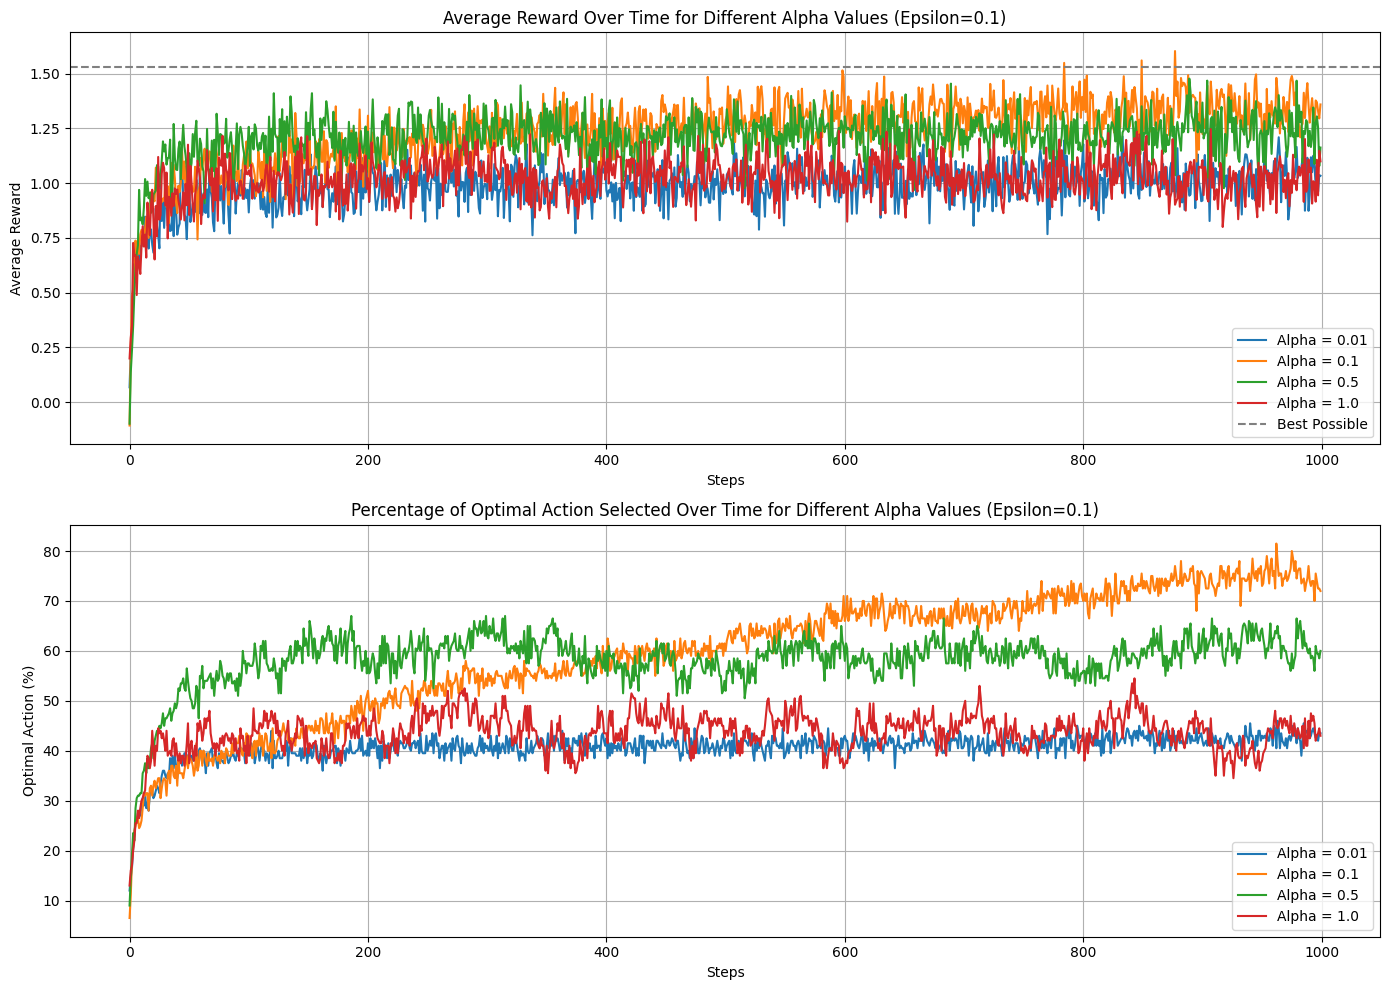

In [12]:
# Define different alpha values to compare for constant step-size
alphas = [0.01, 0.1, 0.5, 1.0]
epsilon_for_alpha_comparison = 0.1 # Keep epsilon fixed for this comparison

# Prepare agent configurations for simulation
agent_configs_alpha_comparison = []
for al in alphas:
    # Ensure use_constant_alpha is True for this comparison
    agent = Agent(num_actions=NUM_ACTIONS, epsilon=epsilon_for_alpha_comparison, alpha=al, use_constant_alpha=True)
    agent_configs_alpha_comparison.append({'label': f'Alpha = {al}', 'agent': agent})

# Run the simulation for all agents in a stationary environment
alpha_rewards, alpha_optimal_actions, alpha_best_possible_rewards = simulate_runs(
    agent_configs_alpha_comparison, NUM_RUNS, NUM_STEPS, NUM_ACTIONS, stationary=True
)

# Calculate average rewards and optimal action percentages for each alpha
avg_rewards_alpha = {label: np.mean(rewards, axis=0) for label, rewards in alpha_rewards.items()}
optimal_action_percentage_alpha = {label: np.mean(actions, axis=0) * 100 for label, actions in alpha_optimal_actions.items()}

# Plotting results
plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
for label, rewards in avg_rewards_alpha.items():
    plt.plot(rewards, label=label)
plt.axhline(
    y=np.mean(alpha_best_possible_rewards),
    linestyle="--",
    color='gray',
    label="Best Possible"
)
plt.title('Average Reward Over Time for Different Alpha Values (Epsilon=0.1)')
plt.xlabel('Steps')
plt.ylabel('Average Reward')
plt.legend(loc='lower right')
plt.grid(True)

plt.subplot(2, 1, 2)
for label, percentages in optimal_action_percentage_alpha.items():
    plt.plot(percentages, label=label)
plt.title('Percentage of Optimal Action Selected Over Time for Different Alpha Values (Epsilon=0.1)')
plt.xlabel('Steps')
plt.ylabel('Optimal Action (%)')
plt.legend(loc='lower right')
plt.grid(True)

plt.tight_layout()
plt.show()

### Interpretation:

The plots demonstrate the impact of the `alpha` (learning rate) parameter in the constant step-size update rule:

*   **`alpha = 0.01` (Slow Learning):** With a very small learning rate, the agent adapts slowly to new information. This results in a gradual increase in average reward and optimal action selection percentage. While eventually converging, it takes longer to reach peak performance, especially if initial estimates are far from true values.

*   **`alpha = 0.1` (Good Balance):** This alpha value typically provides a good balance between responsiveness and stability. The agent learns effectively, showing a relatively quick rise to high average rewards and optimal action selections, and maintaining stable performance thereafter. This is often a good default choice, similar to $\epsilon=0.1$ for exploration.

*   **`alpha = 0.5` (Faster, Noisier):** A higher learning rate leads to faster adaptation. The agent's performance curves rise more steeply initially. However, because new rewards have a stronger influence, the estimates can be more volatile, leading to slightly noisier performance curves, especially in the average reward plot. It reacts quickly but might oscillate more around the optimal values.

*   **`alpha = 1.0` (Highly Unstable):** With `alpha = 1.0`, the estimated value of an action immediately becomes the last reward received for that action (`Q[A] = R`). This makes the estimate extremely sensitive to the most recent experience and highly unstable, especially with stochastic rewards. The average reward and optimal action selection percentage fluctuate wildly, demonstrating that such a high learning rate is generally not effective as it discards all past experience for the most recent one.

In [13]:
# Prepare data for the summary table for alpha comparison
alpha_labels = [config['label'] for config in agent_configs_alpha_comparison]
alpha_final_rewards = [rewards[-1] for rewards in avg_rewards_alpha.values()]
alpha_final_optimal_percentages = [percentages[-1] for percentages in optimal_action_percentage_alpha.values()]

alpha_summary = pd.DataFrame({
    "Agent": alpha_labels,
    "Final Average Reward": alpha_final_rewards,
    "Final Optimal Action %": alpha_final_optimal_percentages
})
display(alpha_summary)

,Agent,Final Average Reward,Final Optimal Action %
0,Alpha = 0.01,1.033872,43.5
1,Alpha = 0.1,1.359391,72.0
2,Alpha = 0.5,1.162524,60.0
3,Alpha = 1.0,1.099614,43.0


## 10. Stationary Environment

A **stationary environment** is one where the underlying true values of the actions (the `q_true` values in our `TenArmedBandit` class) remain constant over time. This is the simplest scenario for a multi-armed bandit problem, and it's the setting in which all our previous experiments (`epsilon` and `alpha` comparisons) have implicitly been conducted.

In a stationary environment, the goal is to accurately estimate the true action values and then exploit the best one. Since the optimal action doesn't change, an agent benefits from converging its estimates to the true values. The sample-average method, which gives decreasing weight to new rewards as more data accumulates, is theoretically well-suited for stationary problems because it eventually converges to the true mean.

Let's explicitly compare the performance of agents using the sample-average update rule versus the constant step-size update rule in this stationary setting. We'll use $\epsilon=0.1$ for both agents to ensure a fair level of exploration.

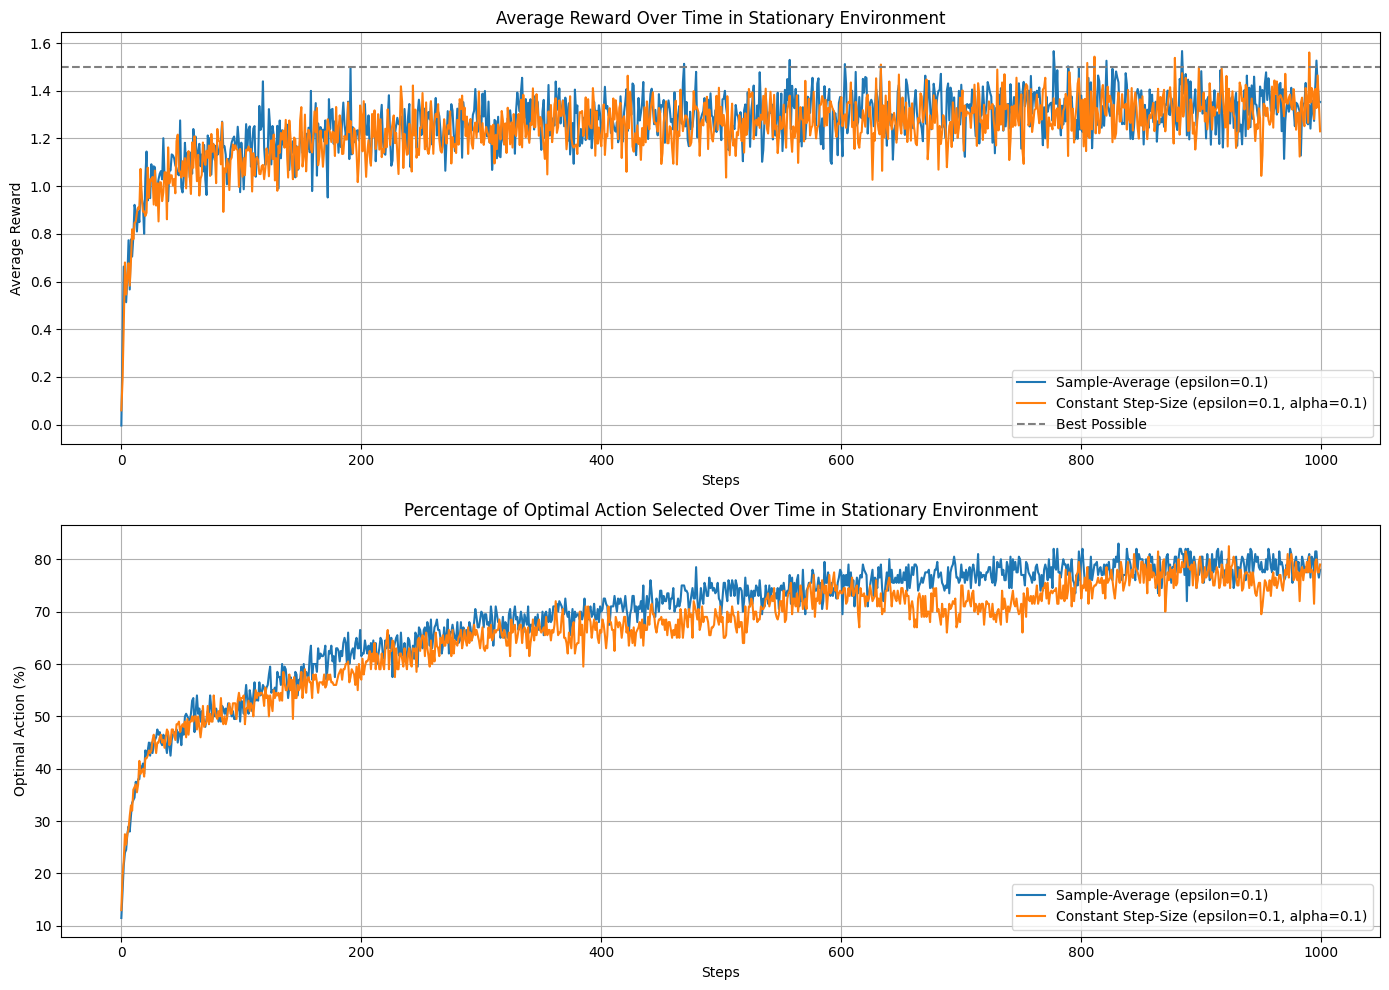

In [14]:
# Define agents for comparison in a stationary environment
epsilon_value = 0.1 # A good balance for exploration

sample_average_agent = Agent(num_actions=NUM_ACTIONS, epsilon=epsilon_value, use_constant_alpha=False)
constant_step_agent = Agent(num_actions=NUM_ACTIONS, epsilon=epsilon_value, alpha=0.1, use_constant_alpha=True) # alpha = 0.1 is a common choice

# Prepare agent configurations
agent_configs_stationary = [
    {'label': 'Sample-Average (epsilon=0.1)', 'agent': sample_average_agent},
    {'label': 'Constant Step-Size (epsilon=0.1, alpha=0.1)', 'agent': constant_step_agent}
]

# Run the simulation in a stationary environment
stationary_rewards, stationary_optimal_actions, stationary_best_possible_rewards = simulate_runs(
    agent_configs_stationary, NUM_RUNS, NUM_STEPS, NUM_ACTIONS, stationary=True
)

# Calculate average rewards and optimal action percentages
avg_rewards_stationary = {label: np.mean(rewards, axis=0) for label, rewards in stationary_rewards.items()}
optimal_action_percentage_stationary = {label: np.mean(actions, axis=0) * 100 for label, actions in stationary_optimal_actions.items()}

# Plotting results
plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
for label, rewards in avg_rewards_stationary.items():
    plt.plot(rewards, label=label)
plt.axhline(
    y=np.mean(stationary_best_possible_rewards),
    linestyle="--",
    color='gray',
    label="Best Possible"
)
plt.title('Average Reward Over Time in Stationary Environment')
plt.xlabel('Steps')
plt.ylabel('Average Reward')
plt.legend(loc='lower right')
plt.grid(True)

plt.subplot(2, 1, 2)
for label, percentages in optimal_action_percentage_stationary.items():
    plt.plot(percentages, label=label)
plt.title('Percentage of Optimal Action Selected Over Time in Stationary Environment')
plt.xlabel('Steps')
plt.ylabel('Optimal Action (%)')
plt.legend(loc='lower right')
plt.grid(True)

plt.tight_layout()
plt.show()

### Interpretation:

In this stationary environment, both the sample-average and constant step-size ($\alpha=0.1$) methods perform quite well, quickly converging to high average rewards and selecting the optimal action most of the time. This is because the true action values are fixed, and both methods are capable of estimating these values over time.

However, we can observe subtle differences:

*   The **Sample-Average** method might appear slightly smoother and more stable in its convergence due to the diminishing step size. As $N[A]$ grows, its estimates become very stable and less susceptible to the noise of individual rewards, effectively converging towards the true mean.
*   The **Constant Step-Size** method, while also performing strongly, might show a bit more 'oscillation' or 'noise' in its later stages, especially in the average reward plot. This is because it continuously gives fixed weight to new rewards, meaning it's always ready to adapt, which can sometimes manifest as slight instability even when the environment is static. Nonetheless, with a reasonable $\alpha$ (like 0.1), it still achieves excellent performance.

For a truly stationary problem, sample-average is often theoretically preferred for its guarantee of convergence to the true mean. However, as we'll see, constant step-size has a critical advantage in dynamic environments.

## 11. Non-Stationary Environment

Most real-world problems are not stationary; the optimal actions or their values can change over time. A **non-stationary environment** in the context of multi-armed bandits means that the true reward values ($q^*$) of the arms are not fixed but instead drift or change over the course of the experiment.

To simulate this, our `TenArmedBandit` class includes a `drift()` method. After each step, if the environment is set to non-stationary, we will add a small random value (e.g., sampled from a normal distribution with mean 0 and a small standard deviation) to each of the true action values. This causes the $q^*$ values to slowly and independently change, meaning the optimal action itself might shift or the relative values of actions might change.

In such an environment, an agent needs to be able to adapt quickly to new information and not rely too heavily on very old data. This is where the characteristics of the sample-average and constant step-size update rules will become even more pronounced.

## 12. Very Important Comparison: Old Information vs. New Information

This section addresses a core difference between the sample-average and constant step-size update rules, especially relevant in **non-stationary environments**.

### Sample-Average Update

*   **Mechanism:** Uses the term $1/N[A]$, where $N[A]$ is the count of times action $A$ has been chosen.
*   **Impact of $N[A]$:** As an action $A$ is selected many times, $N[A]$ becomes large. Consequently, $1/N[A]$ becomes very small.
*   **Weighting:** This means new rewards barely change the estimate $Q[A]$. The estimate becomes heavily weighted towards old, historical rewards.
*   **Adaptability:** It effectively gives too much weight to old rewards. When the environment changes (i.e., true action values drift), the sample-average method adapts very slowly because the influence of new information is diluted by the vast amount of old information it has accumulated.

### Constant Step-Size Update

*   **Mechanism:** Uses a fixed $\alpha$, for example, $\alpha = 0.1$.
*   **Impact of $\alpha$:** The value of $\alpha$ remains constant throughout learning.
*   **Weighting:** New rewards always have the same, fixed influence on the estimate $Q[A]$. It effectively values recent information more, or at least equally to older information.
*   **Adaptability:** When the environment changes, this method adapts much faster because it doesn't diminish the impact of recent experiences. It can effectively 'track' the changes in true action values. This makes it perform better in non-stationary bandits.

We will now run a simulation in a non-stationary environment to observe this critical difference.

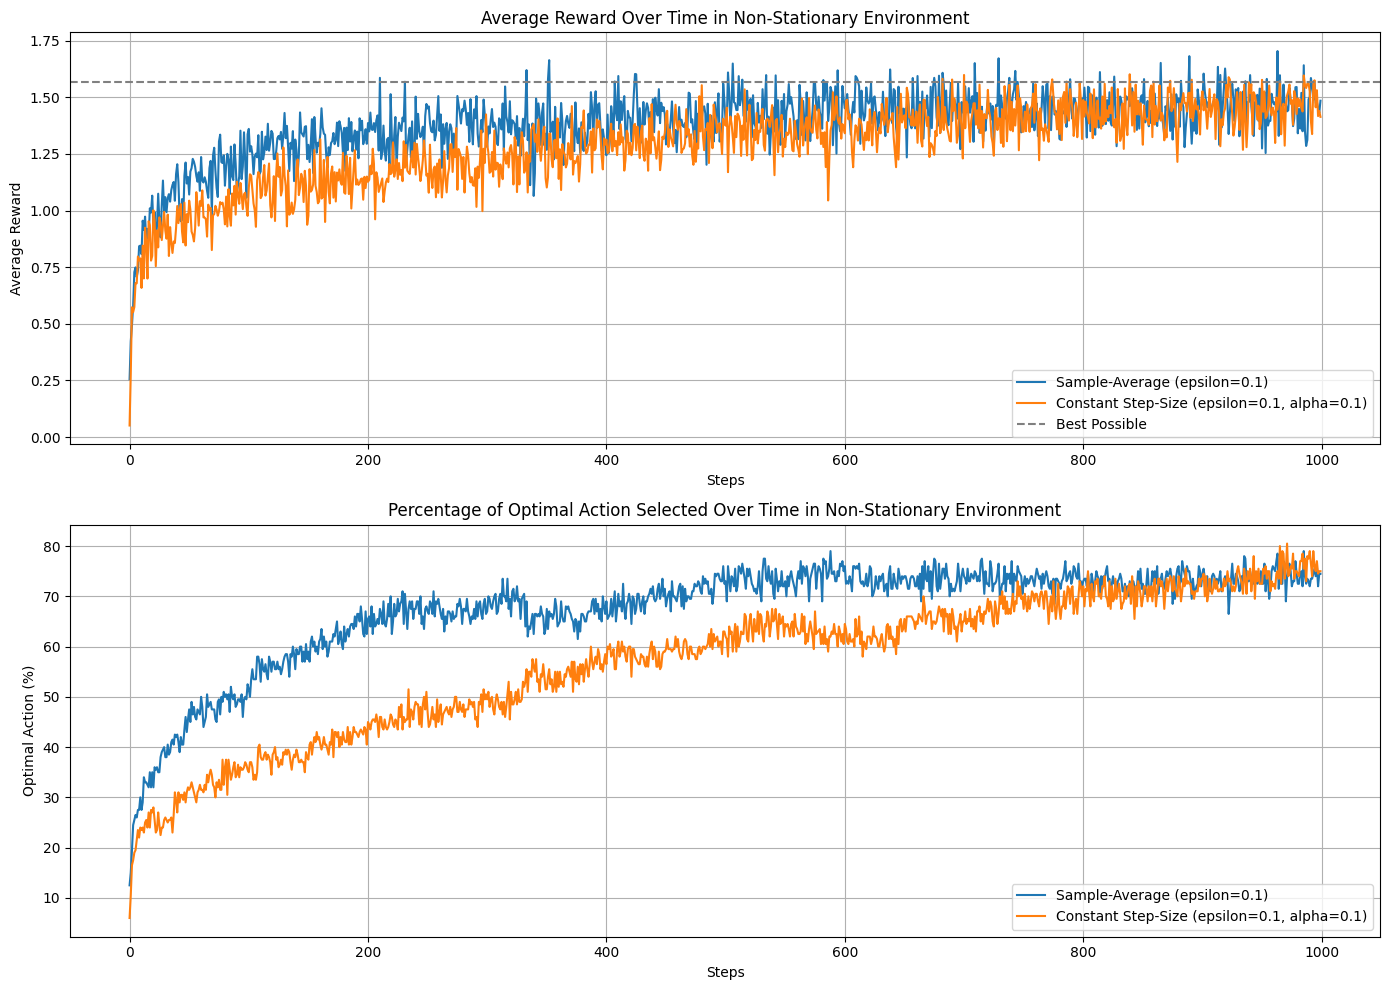

In [15]:
# Define agents for comparison in a non-stationary environment
epsilon_value = 0.1 # A good balance for exploration
alpha_value = 0.1   # A common choice for constant step-size

# Sample-average agent
sample_average_non_stationary_agent = Agent(num_actions=NUM_ACTIONS, epsilon=epsilon_value, use_constant_alpha=False)
# Constant step-size agent
constant_step_non_stationary_agent = Agent(num_actions=NUM_ACTIONS, epsilon=epsilon_value, alpha=alpha_value, use_constant_alpha=True)

# Prepare agent configurations
agent_configs_non_stationary = [
    {'label': 'Sample-Average (epsilon=0.1)', 'agent': sample_average_non_stationary_agent},
    {'label': f'Constant Step-Size (epsilon=0.1, alpha={alpha_value})', 'agent': constant_step_non_stationary_agent}
]

# Run the simulation in a NON-STATIONARY environment
non_stationary_rewards, non_stationary_optimal_actions, non_stationary_best_possible_rewards = simulate_runs(
    agent_configs_non_stationary, NUM_RUNS, NUM_STEPS, NUM_ACTIONS, stationary=False
)

# Calculate average rewards and optimal action percentages
avg_rewards_non_stationary = {label: np.mean(rewards, axis=0) for label, rewards in non_stationary_rewards.items()}
optimal_action_percentage_non_stationary = {label: np.mean(actions, axis=0) * 100 for label, actions in non_stationary_optimal_actions.items()}

# Plotting results
plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
for label, rewards in avg_rewards_non_stationary.items():
    plt.plot(rewards, label=label)
plt.axhline(
    y=np.mean(non_stationary_best_possible_rewards),
    linestyle="--",
    color='gray',
    label="Best Possible"
)
plt.title('Average Reward Over Time in Non-Stationary Environment')
plt.xlabel('Steps')
plt.ylabel('Average Reward')
plt.legend(loc='lower right')
plt.grid(True)

plt.subplot(2, 1, 2)
for label, percentages in optimal_action_percentage_non_stationary.items():
    plt.plot(percentages, label=label)
plt.title('Percentage of Optimal Action Selected Over Time in Non-Stationary Environment')
plt.xlabel('Steps')
plt.ylabel('Optimal Action (%)')
plt.legend(loc='lower right')
plt.grid(True)

plt.tight_layout()
plt.show()

### Interpretation:

The plots from the non-stationary environment clearly highlight the strengths and weaknesses of the two update rules:

*   **Sample-Average Method:** In the average reward plot, the sample-average agent's performance generally lags behind the constant step-size agent. In the optimal action percentage plot, its performance might even degrade or remain at a lower level after an initial climb. This is because, as time progresses and actions are chosen frequently, $N[A]$ becomes very large. New rewards have a minimal impact on the estimated $Q[A]$ values. When the true optimal action shifts due to the environment's drift, the sample-average agent is slow to adapt, clinging to its outdated estimates.

*   **Constant Step-Size Method:** The agent using a constant step-size (e.g., $\alpha=0.1$) generally achieves higher average rewards and maintains a higher percentage of optimal action selections. Because $\alpha$ remains constant, new rewards always have a significant, fixed influence on $Q[A]$. This allows the agent to continuously adapt to the changing true action values, effectively 'forgetting' older, less relevant information and tracking the dynamic optimal action.

This comparison demonstrates that for environments where the underlying reward structure can change, methods that prioritize recent information, such as those using a constant step-size, are often more effective than those that treat all information equally, regardless of its age.

## Tracking Changing Action Values in a Non-Stationary Bandit

To further illustrate why constant step-size methods excel in non-stationary environments, let's visualize how the estimated value of a single action (`q_estimates[0]`) tracks its true value (`q_true[0]`) as it drifts over time. We will compare the tracking ability of a sample-average agent against a constant step-size agent.

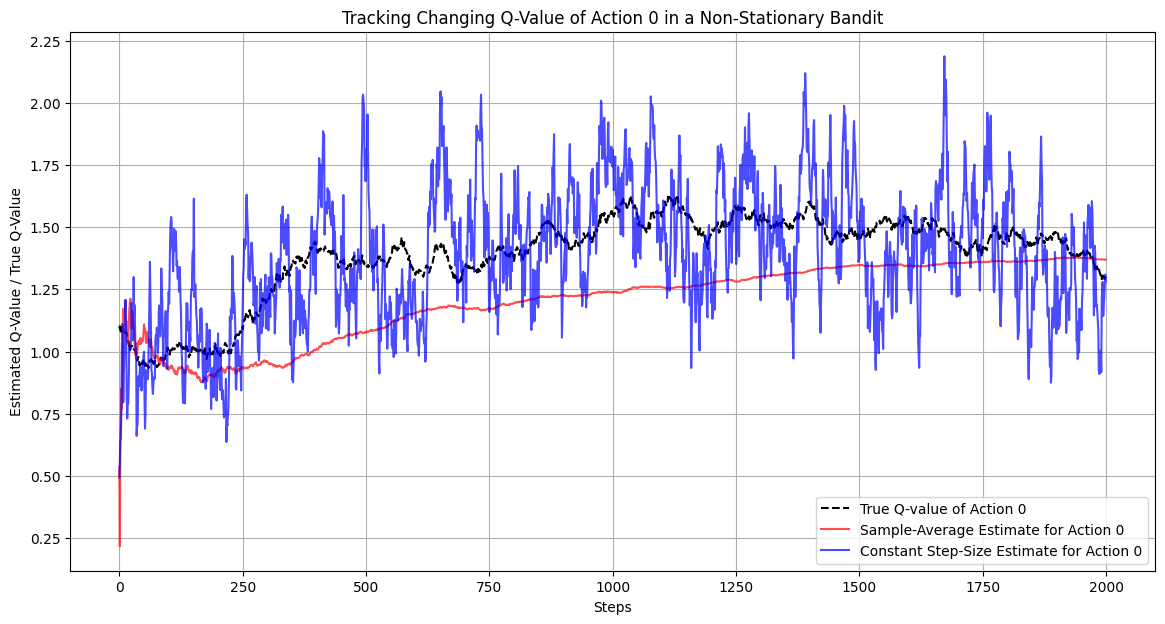

In [16]:
# Experiment parameters for this specific visualization
NUM_STEPS_TRACKING = 2000 # More steps to see drift clearly
TRACKED_ACTION = 0        # We'll track the value of this specific action

# Initialize agents (single run)
# Epsilon won't matter as we are forcing the action choice
sample_avg_tracker_agent = Agent(num_actions=NUM_ACTIONS, epsilon=0.0, use_constant_alpha=False)
constant_step_tracker_agent = Agent(num_actions=NUM_ACTIONS, epsilon=0.0, alpha=0.1, use_constant_alpha=True)

# Initialize non-stationary bandit
tracking_bandit = TenArmedBandit(num_arms=NUM_ACTIONS, stationary=False)

# Storage for tracking
true_q_values = []
sample_avg_estimates = []
constant_step_estimates = []

# Manually track action counts for direct updates
sample_avg_action_counts = np.zeros(NUM_ACTIONS, dtype=int)
constant_step_action_counts = np.zeros(NUM_ACTIONS, dtype=int)

for step in range(NUM_STEPS_TRACKING):
    # Record true Q-value before agents act and bandit drifts
    true_q_values.append(tracking_bandit.q_true[TRACKED_ACTION])

    # Simulate interaction for sample-average agent, forcing it to pull TRACKED_ACTION
    sample_avg_action_counts[TRACKED_ACTION] += 1
    reward_sa = tracking_bandit.pull_arm(TRACKED_ACTION)
    # Apply sample-average update specifically to TRACKED_ACTION's estimate
    sample_avg_tracker_agent.q_estimates[TRACKED_ACTION] += \
        (1 / sample_avg_action_counts[TRACKED_ACTION]) * \
        (reward_sa - sample_avg_tracker_agent.q_estimates[TRACKED_ACTION])
    sample_avg_estimates.append(sample_avg_tracker_agent.q_estimates[TRACKED_ACTION])


    # Simulate interaction for constant step-size agent, forcing it to pull TRACKED_ACTION
    constant_step_action_counts[TRACKED_ACTION] += 1 # Update count for consistency, though not used in update formula
    reward_cs = tracking_bandit.pull_arm(TRACKED_ACTION)
    # Apply constant step-size update specifically to TRACKED_ACTION's estimate
    constant_step_tracker_agent.q_estimates[TRACKED_ACTION] += \
        constant_step_tracker_agent.alpha * \
        (reward_cs - constant_step_tracker_agent.q_estimates[TRACKED_ACTION])
    constant_step_estimates.append(constant_step_tracker_agent.q_estimates[TRACKED_ACTION])

    # Drift the bandit's true values
    tracking_bandit.drift()

plt.figure(figsize=(14, 7))
plt.plot(true_q_values, label=f'True Q-value of Action {TRACKED_ACTION}', color='black', linestyle='--')
plt.plot(sample_avg_estimates, label=f'Sample-Average Estimate for Action {TRACKED_ACTION}', color='red', alpha=0.7)
plt.plot(constant_step_estimates, label=f'Constant Step-Size Estimate for Action {TRACKED_ACTION}', color='blue', alpha=0.7)

plt.title(f'Tracking Changing Q-Value of Action {TRACKED_ACTION} in a Non-Stationary Bandit')
plt.xlabel('Steps')
plt.ylabel('Estimated Q-Value / True Q-Value')
plt.legend()
plt.grid(True)
plt.show()

### Interpretation:

The visualization above clearly demonstrates the difference in adaptation between the two update rules in a non-stationary environment:

*   **True Q-value (black dashed line):** This line shows how the actual reward potential of Action 0 drifts over time, reflecting the non-stationary nature of the environment.

*   **Sample-Average Estimate (red line):** Notice how the sample-average estimate lags significantly behind the true Q-value. It reacts very slowly to changes. This is because, as more steps accumulate, the $1/N[A]$ term becomes very small, making it difficult for recent rewards to significantly alter the estimate, which is heavily influenced by a large history of old data.

*   **Constant Step-Size Estimate (blue line):** In contrast, the constant step-size estimate tracks the true Q-value much more closely. While it might show some oscillation due to the stochastic nature of rewards and the constant update factor, it consistently adapts to the changing true value. This responsiveness is due to the fixed $\alpha$ (e.g., 0.1), which ensures that new information always has a substantial impact on the estimate, allowing the agent to 'forget' old, potentially irrelevant information and continuously adapt to the current environmental dynamics.

This experiment visually confirms that for non-stationary problems, a constant step-size is crucial for maintaining accurate action value estimates and thus achieving better performance.

## Revisit: Experiment Setup and Repeated Runs

Throughout these experiments, we consistently used the following parameters:

*   `num_actions = 10`
*   `num_runs = 200`
*   `num_steps = 1000`

It is crucial to understand *why* we average our results over `NUM_RUNS = 200` independent experiments, each consisting of `NUM_STEPS = 1000` time steps.

### Importance of Repeated Experiments:

1.  **Randomness in Rewards:** The rewards received from pulling an arm are stochastic (randomly sampled from a distribution), not deterministic. A single run might, by chance, get a sequence of unusually high or low rewards for a particular action, leading to misleading conclusions about the agent's performance.
2.  **Randomness in Exploration:** For $\epsilon$-greedy agents (with $\epsilon > 0$), the choice to explore is random. This means the agent's path through the environment can vary significantly from one run to another.

By running the simulation many times and averaging the results (e.g., average reward, percentage of optimal action selected), we mitigate the impact of this inherent randomness. The average performance across many runs provides a more reliable and generalizable measure of an agent's true effectiveness, smoothing out statistical fluctuations and giving us a clearer picture of its expected behavior.

## 14. Final Conclusion (Portfolio-Style)

This comprehensive Jupyter Notebook project has thoroughly explored the fundamental concepts of Reinforcement Learning through the lens of the Multi-Armed Bandit problem. We've gained critical insights into agent design, learning mechanisms, and their performance in various environmental conditions.

Key takeaways from our experiments include:

*   **The Exploration-Exploitation Dilemma is Central:** Agents must balance leveraging current knowledge (exploitation) with seeking new information (exploration) to maximize long-term rewards.

*   **Greedy Agents are Often Suboptimal:** Purely greedy agents, by exclusively exploiting their current best belief, are highly susceptible to getting stuck in suboptimal local maxima, failing to discover truly better options. They can perform well only if they discover the best action early by chance.

*   **Epsilon-Greedy as a Robust Solution:** The $\epsilon$-greedy strategy provides a robust and effective approach to this dilemma. By introducing a small probability of random action selection, it ensures continuous exploration.

*   **Optimal Epsilon Balance:** Our comparison showed that an $\epsilon$ value around `0.1` typically strikes an excellent balance, allowing sufficient discovery of optimal actions without excessive waste from random choices. Conversely, very high $\epsilon$ values lead to over-exploration, which significantly lowers overall rewards.

*   **Update Rules and Environmental Dynamics:**
    *   **Sample-Average:** This update rule is well-suited for **stationary environments**, where action values are fixed. It provides unbiased estimates that converge to the true means, becoming very stable over time. However, its diminishing step-size (`1/N`) means new information has a progressively smaller impact as more data accumulates.
    *   **Constant Step-Size:** Critically, this update rule (using a fixed $\alpha$) is superior for **non-stationary environments** where action values drift. By continuously giving a fixed weight to recent rewards, it effectively prioritizes new information. This allows the agent to adapt much faster to changes, continuously 'tracking' the moving optimal actions, as visually demonstrated in our tracking experiment. The drawback is that it might be more susceptible to noise if $\alpha$ is too high.

This project demonstrates core Reinforcement Learning skills, including:

*   **Designing Agents and Environments:** Implementing classes for both the bandit environment and various learning agents.
*   **Handling Reward Feedback:** Processing environmental responses to update internal state.
*   **Implementing Exploration Strategies:** Understanding and applying methods like $\epsilon$-greedy.
*   **Comparing Learning Rates and Update Rules:** Evaluating the impact of different learning parameters ($\epsilon$, $\alpha$) and update mechanisms (sample-average vs. constant step-size).
*   **Conducting Robust Experiments:** Using repeated runs (`NUM_RUNS`) to average out stochasticity and ensure reliable results.
*   **Performing Visual and Interpretative Analysis:** Clearly presenting findings through graphs and providing concise interpretations.

This notebook serves as a foundational exploration into reinforcement learning principles, providing a strong basis for understanding more complex algorithms and real-world applications.

## Optional Demo: Watching the Agent Learn Step by Step

This final animation is a single demonstration run.  
It is included to make the agent's learning process easier to understand visually.

In the animation:
- The blue bars show the agent's estimated Q-values for each arm.
- The orange X markers show the true hidden value of each arm.
- The dashed line shows the best possible true value.
- The highlighted bar shows the arm chosen by the agent at that step.

At each step, the agent chooses an arm, receives a reward, and updates its estimated value for that arm.

This demo is for visual understanding only.  
The main conclusions of the project come from the averaged experiment graphs above, because those use many independent runs and are more reliable.

In [17]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

num_actions = 10
num_steps_animation = 100
epsilon = 0.1
alpha = 0.1

bandit_demo = TenArmedBandit(num_arms=num_actions, stationary=True)
q_estimates = np.zeros(num_actions)

q_history = []
chosen_actions = []
reward_history = []

for step in range(num_steps_animation):

    if np.random.random() < epsilon:
        action = np.random.randint(num_actions)
    else:
        action = custom_argmax(q_estimates)

    reward = bandit_demo.pull_arm(action)

    q_estimates[action] = q_estimates[action] + alpha * (reward - q_estimates[action])

    q_history.append(q_estimates.copy())
    chosen_actions.append(action)
    reward_history.append(reward)

all_q_values = np.array(q_history)
y_min = min(np.min(all_q_values), np.min(bandit_demo.q_true)) - 1
y_max = max(np.max(all_q_values), np.max(bandit_demo.q_true)) + 1

fig, ax = plt.subplots(figsize=(11, 5))

def update(frame):
    ax.clear()

    q_values = q_history[frame]
    chosen_action = chosen_actions[frame]
    reward = reward_history[frame]

    bars = ax.bar(
        range(num_actions),
        q_values,
        alpha=0.75,
        label="Estimated Q-values"
    )

    bars[chosen_action].set_edgecolor("black")
    bars[chosen_action].set_linewidth(3)

    ax.scatter(
        range(num_actions),
        bandit_demo.q_true,
        marker="x",
        s=120,
        label="True hidden action values"
    )

    ax.axhline(
        y=np.max(bandit_demo.q_true),
        linestyle="--",
        label="Best possible true value"
    )

    ax.set_title(
        f"Step {frame + 1}: Agent chose Arm {chosen_action}, Reward = {reward:.2f}"
    )
    ax.set_xlabel("Arm / Action")
    ax.set_ylabel("Value")
    ax.set_xticks(range(num_actions))
    ax.set_ylim(y_min, y_max)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right")

animation = FuncAnimation(
    fig,
    update,
    frames=num_steps_animation,
    interval=250,
    repeat=False
)

plt.close(fig)

HTML(animation.to_jshtml())